# Pipeline Anomaly Detection

This notebook demonstrates a compact applied ML workflow for anomaly detection on pipeline-style operational data using **Isolation Forest**, **Random Forest**, and a **PyTorch autoencoder**.

In [1]:
from anomaly_pipeline.feature_engineering import load_and_engineer_features
from anomaly_pipeline.model_training import (
    train_isolation_forest,
    train_random_forest,
    train_autoencoder_anomaly_detector,
)
from anomaly_pipeline.reporting import metrics_table
import matplotlib.pyplot as plt

In [2]:
df, X, y = load_and_engineer_features("../data/sample_pipeline_data.csv", short_window=5, long_window=12)
df.head()

,timestamp,pressure_psi,flow_rate_m3h,temperature_c,is_anomaly,anomaly_type,pressure_flow_ratio,hour_sin,hour_cos,pressure_diff,...,pressure_roll_std_5,pressure_zscore_12,flow_diff,flow_roll_mean_5,flow_roll_std_5,flow_zscore_12,temperature_diff,temperature_roll_mean_5,temperature_roll_std_5,temperature_zscore_12
0,2025-01-01 00:00:00,102.274,63.385,14.535,0,normal,1.613536,0.000000,1.000000,0.000,...,0.000000,0.000000,0.000,63.385000,0.000000,0.000000,0.000,14.5350,0.000000,0.000000
1,2025-01-01 01:00:00,102.099,64.734,15.477,0,normal,1.577208,0.258819,0.965926,-0.175,...,0.123744,0.000000,1.349,64.059500,0.953887,0.000000,0.942,15.0060,0.666095,0.000000
2,2025-01-01 02:00:00,104.675,60.294,14.475,0,normal,1.736077,0.500000,0.866025,2.576,...,1.439398,1.152565,-4.440,62.804333,2.276243,-1.102841,-1.002,14.8290,0.561986,-0.629909
3,2025-01-01 03:00:00,105.675,60.679,16.679,0,normal,1.741542,0.707107,0.707107,1.000,...,1.774490,1.123844,0.385,62.273000,2.140899,-0.744547,2.204,15.2915,1.032558,1.343750
4,2025-01-01 04:00:00,103.708,60.643,15.793,0,normal,1.710140,0.866025,0.500000,-1.967,...,1.536802,0.014185,-0.036,61.947000,1.992226,-0.654544,-0.886,15.3918,0.921918,0.435180


In [3]:
print(f"Rows: {len(df)}")
print(f"Anomaly rate: {y.mean():.3%}")

Rows: 720
Anomaly rate: 5.278%


## Random Forest baseline
The Random Forest is included as a supervised benchmark because this synthetic dataset has labels.

In [4]:
iso = train_isolation_forest(X, y)
iso.metrics

{'precision': 0.7272727272727273,
 'recall': 0.8421052631578947,
 'f1': 0.7804878048780488,
 'true_negative': 670,
 'false_positive': 12,
 'false_negative': 6,
 'true_positive': 32,
 'roc_auc': 0.9858388640222256,
 'average_precision': 0.7639344226266103}

## Isolation Forest
The Isolation Forest is useful when labels are limited. Main question is how does an unsupervised baseline compare with a supervised one?

In [5]:
rf = train_random_forest(X, y)
rf.metrics

{'precision': 1.0,
 'recall': 0.9736842105263158,
 'f1': 0.9866666666666667,
 'true_negative': 682,
 'false_positive': 0,
 'false_negative': 1,
 'true_positive': 37,
 'roc_auc': 1.0,
 'average_precision': 0.9999999999999998}

## PyTorch autoencoder

PyTorch autoencoder demonstrates a simple deep-learning anomaly detector using reconstruction error.

In [6]:
ae = train_autoencoder_anomaly_detector(X, y)
ae.metrics

{'precision': 0.7586206896551724,
 'recall': 0.5789473684210527,
 'f1': 0.6567164179104478,
 'true_negative': 675,
 'false_positive': 7,
 'false_negative': 16,
 'true_positive': 22,
 'roc_auc': 0.9467510418274425,
 'average_precision': 0.7174825772862659}

In [7]:
metrics_table([iso,rf,ae])

,model,precision,recall,f1,true_negative,false_positive,false_negative,true_positive,roc_auc,average_precision
0,Random Forest,1.000000,0.973684,0.986667,682,0,1,37,1.000000,1.000000
1,Isolation Forest,0.727273,0.842105,0.780488,670,12,6,32,0.985839,0.763934
2,PyTorch Autoencoder,0.758621,0.578947,0.656716,675,7,16,22,0.946751,0.717483


The supervised Random Forest wins on this labeled dataset. That is not surprising, but it is still useful: it tells me the engineered features are informative.

The more interesting comparison is between Isolation Forest and the autoencoder. Isolation Forest catches more anomalies here, while the autoencoder is more conservative and depends strongly on threshold choice.

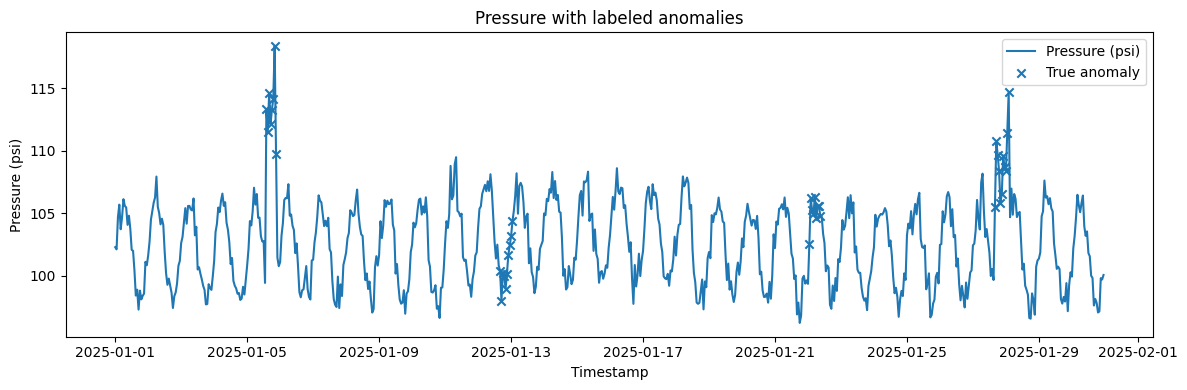

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], df["pressure_psi"], label="Pressure (psi)")
plt.scatter(df.loc[y == 1, "timestamp"],
            df.loc[y == 1, "pressure_psi"],
            label="True anomaly", marker="x")
plt.title("Pressure with labeled anomalies")
plt.xlabel("Timestamp")
plt.ylabel("Pressure (psi)")
plt.legend()
plt.tight_layout()
plt.show()

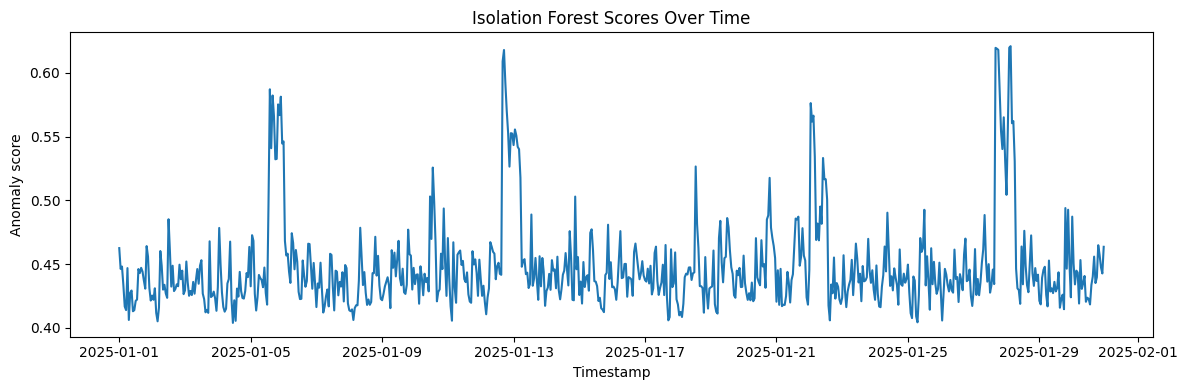

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], iso.scores, label="Isolation Forest anomaly score")
plt.title("Isolation Forest Scores Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Anomaly score")
plt.tight_layout()
plt.show()

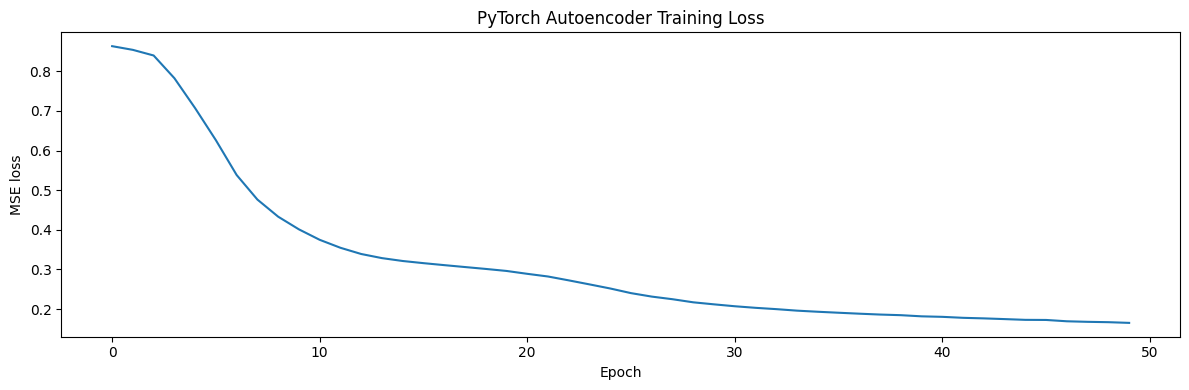

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(ae.artifacts["history"])
plt.title("PyTorch Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.tight_layout()
plt.show()

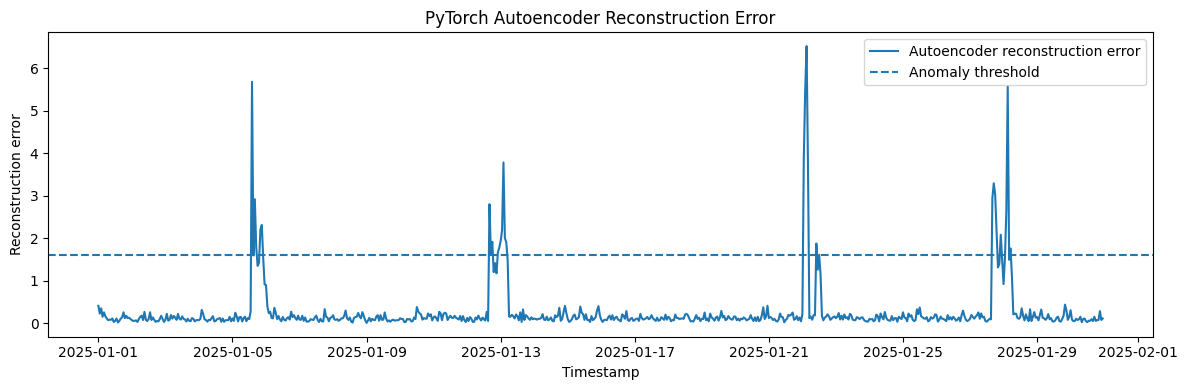

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], ae.scores, label="Autoencoder reconstruction error")
plt.axhline(ae.artifacts["threshold"], linestyle="--", label="Anomaly threshold")
plt.title("PyTorch Autoencoder Reconstruction Error")
plt.xlabel("Timestamp")
plt.ylabel("Reconstruction error")
plt.legend()
plt.tight_layout()
plt.show()

## Precision-Recall Curve

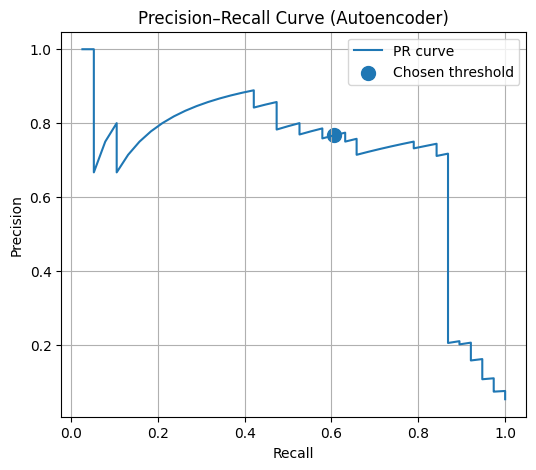

In [13]:
pr = ae.artifacts["pr_table"]
plt.figure(figsize=(6,5))
plt.plot(pr["recall"], pr["precision"], label="PR curve")
i = (pr["threshold"] - ae.artifacts["threshold"]).abs().idxmin()
plt.scatter(pr.loc[i,"recall"], pr.loc[i,"precision"], s=100, label="Chosen threshold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Autoencoder)")
plt.legend()
plt.grid(True)

plt.show()

## Feature importance

The strongest Random Forest feature was `pressure_flow_ratio`, followed by temperature and rolling flow statistics. That aligns with how anomalies were injected: several abnormal windows were created by making pressure and flow diverge rather than just moving one variable in isolation.

In [14]:
rf.artifacts["feature_importance"].head(8)

,feature,importance
0,pressure_flow_ratio,0.211151
1,temperature_c,0.146457
2,flow_roll_mean_5,0.108626
3,flow_rate_m3h,0.094565
4,temperature_roll_mean_5,0.087593
5,pressure_roll_std_5,0.070433
6,pressure_psi,0.060339
7,temperature_roll_std_5,0.040728


## Threshold sensitivity

The autoencoder looked promising when ranked by reconstruction error, but a threshold still had to be chosen. I used the 96th percentile because lower thresholds created too many alerts, while higher thresholds missed medium-strength anomalous windows.

In [16]:
print(f"Last 5 epochs in training history:")
for epoch, train_loss in enumerate(ae.artifacts["history"][-5:], start=len(ae.artifacts["history"])-4):
    print(f"Epoch {epoch}: {train_loss}")

Last 5 epochs in training history:
Epoch 46: 0.1725487741600733
Epoch 47: 0.169213328892884
Epoch 48: 0.16782052087381788
Epoch 49: 0.16692683799875097
Epoch 50: 0.16515596626091564
